In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
batch_size = 128

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 33.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 956kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 8.90MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.59MB/s]


In [3]:
class VAE(nn.Module):

    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def encode(self, x):
        h = self.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        z = mu + epsilon * std
        return z

    def decode(self, z):
        h = self.relu(self.fc2(z))
        x_reconstructed = self.sigmoid(self.fc3(h))
        return x_reconstructed

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstructed = self.decode(z)
        return reconstructed, mu, logvar

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VAE().to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [5]:
def loss_function(reconstructed_x, x, mu, logvar):

    reconstruction_loss = nn.functional.binary_cross_entropy(
        reconstructed_x, x, reduction='sum'
    )

    kl_divergence = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return reconstruction_loss, kl_divergence

In [6]:
epochs = 10

for epoch in range(epochs):

    total_loss = 0
    total_recon = 0
    total_kl = 0

    for data, _ in train_loader:

        data = data.view(-1, 784).to(device)

        optimizer.zero_grad()

        reconstructed, mu, logvar = model(data)

        recon_loss, kl_loss = loss_function(reconstructed, data, mu, logvar)

        loss = recon_loss + kl_loss

        loss.backward()

        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Total Loss: {total_loss:.2f}")
    print(f"Reconstruction Loss: {total_recon:.2f}")
    print(f"KL Divergence Loss: {total_kl:.2f}")
    print("------------------------------------------------")

Epoch [1/10]
Total Loss: 9920754.47
Reconstruction Loss: 9005661.25
KL Divergence Loss: 915093.24
------------------------------------------------
Epoch [2/10]
Total Loss: 7298402.70
Reconstruction Loss: 5956572.07
KL Divergence Loss: 1341830.62
------------------------------------------------
Epoch [3/10]
Total Loss: 6875720.87
Reconstruction Loss: 5433163.00
KL Divergence Loss: 1442557.85
------------------------------------------------
Epoch [4/10]
Total Loss: 6695482.42
Reconstruction Loss: 5218661.75
KL Divergence Loss: 1476820.67
------------------------------------------------
Epoch [5/10]
Total Loss: 6591009.83
Reconstruction Loss: 5099426.91
KL Divergence Loss: 1491582.93
------------------------------------------------
Epoch [6/10]
Total Loss: 6520543.62
Reconstruction Loss: 5019558.78
KL Divergence Loss: 1500984.84
------------------------------------------------
Epoch [7/10]
Total Loss: 6472489.06
Reconstruction Loss: 4966400.63
KL Divergence Loss: 1506088.41
--------------

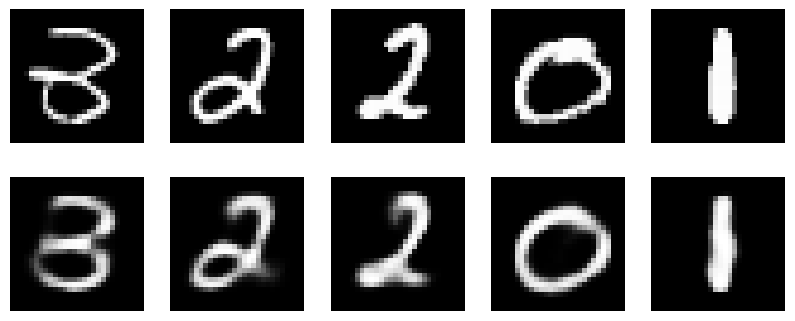

In [7]:
data_iter = iter(train_loader)
images, _ = next(data_iter)

images = images.view(-1,784).to(device)

reconstructed, _, _ = model(images)

images = images.view(-1,1,28,28).cpu().detach()
reconstructed = reconstructed.view(-1,1,28,28).cpu().detach()

plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i][0], cmap='gray')
    plt.axis('off')

for i in range(5):
    plt.subplot(2,5,i+6)
    plt.imshow(reconstructed[i][0], cmap='gray')
    plt.axis('off')

plt.show()